# A. Importation of libraries and Configs

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
from datetime import datetime

In [2]:
class Config:
    # Path to the pseudonimized revenues dataset
    dataset_dir = r"Database\revenues_pseudonymized.xlsx"
    # Path to the enrollee infos
    enrollees_dir = r"Database\enrollees_pseudonymized.xlsx"
    # Path to the machine learning model parameters
    parameters_dir = r"machine_learning\parameters.json"

    # Path to cache directory to store preprocessed dataset if needed
    cache_dir = ""
    load_cache = True

    # Path to store transformer results
    results_dir = r"C:\Users\rjbel\Python\Data\Thesis\Results"


    # The date used
    observation_end = datetime.today()

    # Class to predict
    target_feature = 'dtp_bracket'
    # Test size in %
    test_size = 0.3

    # Time points used in generating survival features
    # It's not until 120 since the earliest pre-payment is 288 days
    time_points = [30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, 390, 420, 450]


args = Config()

# B. Loading of datasets

## 1. Revenues

In [3]:
df_revenues = pd.read_excel(args.dataset_dir)

In [4]:
df_revenues

,entry_number,entry_date,due_date,school_year,student_id_pseudonimized,category_name,discount_refund_applied_to,amount_due,amount_paid,account_name,receivables
0,0,2025-10-13,2025-10-13,2014,9XBPS6GQ,Form 137,NaN,150.0,150.0,G-Cash,0.0
1,1,2016-01-01,2016-01-01,2016,QCNXOF71,Back Account,NaN,3524.0,0.0,Not Applicable,3524.0
2,2,2016-01-01,2016-01-01,2016,UFN5RBCA,Back Account,NaN,9831.0,0.0,Not Applicable,9831.0
3,3,2016-01-01,2016-01-01,2016,CATF26JR,Back Account,NaN,9240.0,0.0,Not Applicable,9240.0
4,4,2016-01-01,2016-01-01,2016,TE11Z2LJ,Back Account,NaN,5886.0,0.0,Not Applicable,5886.0
...,...,...,...,...,...,...,...,...,...,...,...
52779,53991,2026-03-25,2026-07-11,2026,EUODMYKY,Discount - Pastoral,G04-A-UE,-15400.0,0.0,Not Applicable,-15400.0
52780,53992,2026-03-25,2026-07-11,2026,EUODMYKY,Discount - Reservee,G04-A-UE,-2000.0,0.0,Not Applicable,-2000.0
52781,53993,2026-03-25,2026-07-11,2026,EUODMYKY,G04-OF-Full,NaN,17900.0,16300.0,Bank,1600.0
52782,53994,2026-03-25,2026-07-11,2026,EUODMYKY,G04-OF-Full,NaN,0.0,1600.0,Cash,-1600.0


## 2. Enrollees

In [5]:
df_enrollees = pd.read_excel(args.enrollees_dir)

In [6]:
df_enrollees

,school_year,student_id_pseudonimized,plan_type,grade_level,enrollment_date,education_level,has_refunded
0,2018,08GNGU9D,Plan - D,G03,2018-06-07,Elementary,No Refund
1,2018,0JWX77BI,Plan - B,SpE,2018-06-07,Special Education,No Refund
2,2018,0LZJ7928,Plan - A,G01,2018-05-18,Elementary,No Refund
3,2018,15RI5SWE,Plan - B,G03,2018-06-06,Elementary,No Refund
4,2018,1IGM0VHQ,Plan - A,G01,2018-05-04,Elementary,No Refund
...,...,...,...,...,...,...,...
2718,2026,YMJ3L6X6,Plan - B,G08,2026-01-19,Junior High,No Refund
2719,2026,YNT1UYY7,Plan - A,SpE,2026-01-31,Special Education,No Refund
2720,2026,Z3FMQ7JI,Plan - A,G05,2026-01-09,Elementary,No Refund
2721,2026,ZHRMZVJR,Plan - C,G06,2026-03-16,Elementary,No Refund


## 3. Credit Sales

In [7]:
from feature_engineering.credit_sales_machine_learning import CreditSalesProcessor

cs = CreditSalesProcessor(df_revenues, df_enrollees, args)
df_credit_sales = cs.show_data()

Single due date records:   10354
Multiple due date records: 289


In [8]:
df_credit_sales

,school_year,student_id_pseudonimized,category_name,gross_receivables,amount_discounted,adjustments,credit_sale_amount,due_date,date_fully_paid,days_elapsed_until_fully_paid,...,due_month,due_quarter,opening_balance_flag,payment_ratio,early_payer_flag,on_time_streak,prev_bracket,dtp_rolling_std,dtp_max,plan_type_risk_score
2274,2022,02PNVPI5,Kn2-C-1st,2800.0,0.0,0.0,2800.0,2022-09-09,2022-09-06,-3,...,9,3,0,1.034215,NaN,0,NaN,<NA>,<NA>,0
2554,2022,02PNVPI5,Kn2-C-2nd,2800.0,0.0,0.0,2800.0,2022-11-05,NaT,1236,...,11,4,1,0.943797,1.0,1,0.0,<NA>,-3,0
2920,2022,02PNVPI5,Kn2-OF-2nd,2267.0,0.0,0.0,2267.0,2022-12-05,NaT,1206,...,12,4,1,0.881408,NaN,0,NaN,<NA>,-3,0
2971,2022,02PNVPI5,Kn2 - Moving Up - Male,2600.0,0.0,0.0,2600.0,2022-12-16,NaT,1195,...,12,4,1,0.805478,NaN,0,NaN,<NA>,-3,0
2972,2022,02PNVPI5,Surcharge,336.0,0.0,0.0,336.0,2022-12-16,NaT,1195,...,12,4,1,0.805478,NaN,0,NaN,<NA>,<NA>,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9734,2025,ZXPL0CI9,G06-C-4th,5800.0,0.0,0.0,5800.0,2026-02-06,2026-02-09,3,...,2,1,1,0.972245,0.0,0,2.0,10.456258,34,0
9892,2025,ZXPL0CI9,Graduation - Other Services,1500.0,0.0,0.0,1500.0,2026-02-18,2026-03-23,33,...,2,1,1,0.992873,0.0,0,1.0,14.614491,34,0
9901,2025,ZXPL0CI9,Events - Foundation,400.0,0.0,0.0,400.0,2026-03-05,2026-03-11,6,...,3,1,1,0.990990,0.0,0,2.0,15.340578,34,0
10201,2025,ZXPL0CI9,G06-OF-3rd,5800.0,0.0,0.0,5800.0,2026-03-06,2026-03-11,5,...,3,1,1,0.964462,0.0,0,1.0,16.792856,34,0


In [9]:
df_credit_sales.to_excel("credit_sale_invoices.xlsx", index=False)

# C. Exploratory Data Analysis

In [10]:
# Get counts
counts = df_credit_sales.dtp_bracket.value_counts()

# Convert to percentages
percentages = counts / counts.sum() * 100

# Combine into one DataFrame
result = pd.DataFrame({
    'count': counts,
    'percentage': percentages.round(2)
})

print(result)

             count  percentage
dtp_bracket                   
on_time       3879       39.61
30_days       2969       30.32
90_days       1880       19.20
60_days       1065       10.88


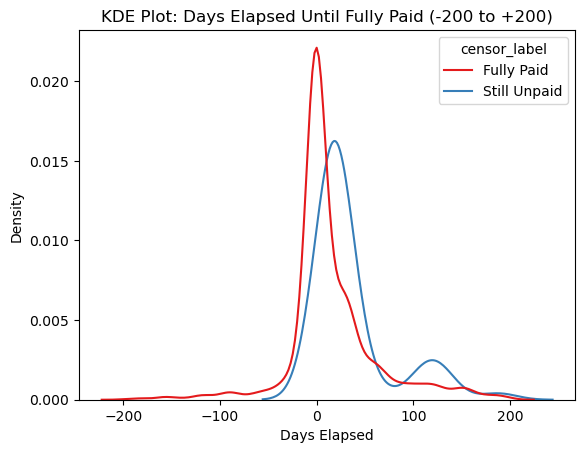

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Remove those that have no full dtp_history:
df_filtered = df_credit_sales.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'])


# Clean and filter directly on the DataFrame
df_filtered = df_filtered.loc[
    df_filtered['days_elapsed_until_fully_paid']
        .replace("", np.nan)   # replace empty strings with NaN
        .dropna()              # drop NaNs
        .index                 # keep aligned index
]


# Apply numeric filter
df_filtered = df_filtered[
    (df_filtered['days_elapsed_until_fully_paid'] >= -200) &
    (df_filtered['days_elapsed_until_fully_paid'] <= 200)
]

# Convert censor column to categorical with labels
df_filtered["censor_label"] = (
    df_filtered["censor"]
    .map({0: "Still Unpaid", 1: "Fully Paid"})
    .astype("category")   # force categorical type
)


# KDE plot with grouping by categorical censor labels
sns.kdeplot(
    data=df_filtered,
    x="days_elapsed_until_fully_paid",
    hue="censor_label",
    fill=False,
    common_norm=False,
    palette="Set1"
)

plt.title("KDE Plot: Days Elapsed Until Fully Paid (-200 to +200)")
plt.xlabel("Days Elapsed")
plt.ylabel("Density")
plt.show()

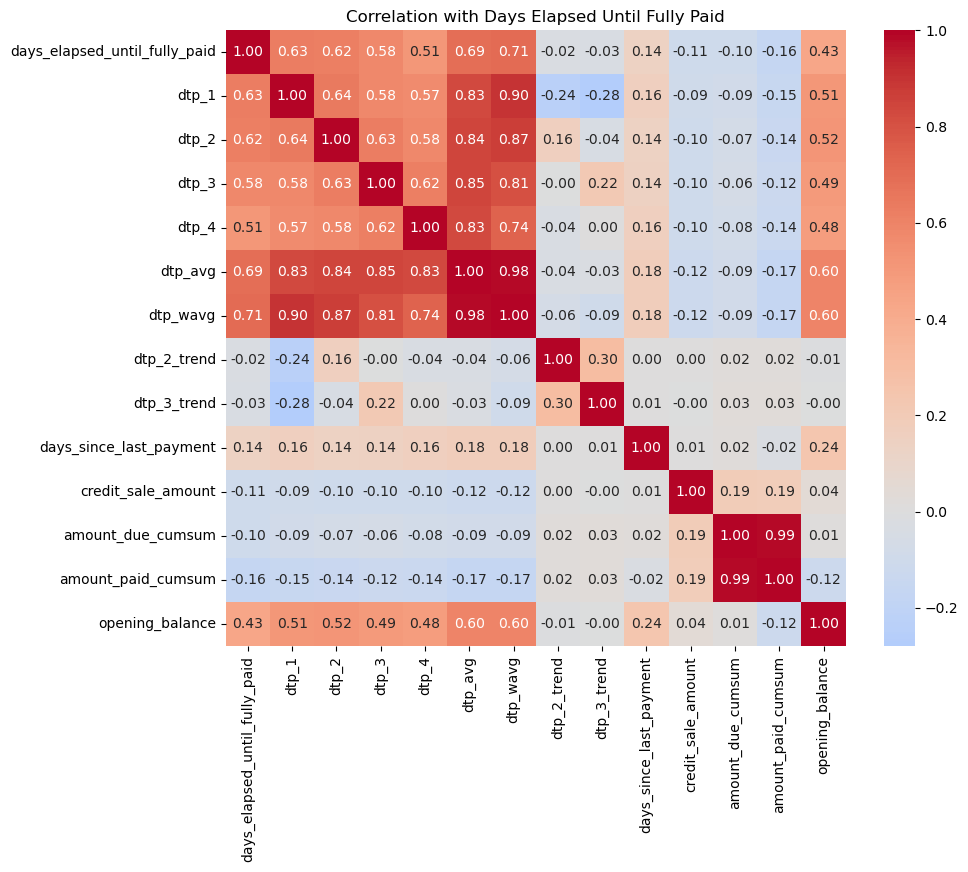

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df_filtered = df_credit_sales[df_credit_sales['censor'] == 1]
df_filtered = df_filtered.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'])

# Select relevant columns
cols = ['days_elapsed_until_fully_paid', 
        'dtp_1', 'dtp_2', 'dtp_3', 'dtp_4', 
        'dtp_avg', 'dtp_wavg', 'dtp_2_trend',
        'dtp_3_trend', 'days_since_last_payment',
        'credit_sale_amount', 'amount_due_cumsum',
        'amount_paid_cumsum', 'opening_balance']

# Compute correlation matrix
corr = df_filtered[cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Correlation with Days Elapsed Until Fully Paid")
plt.show()

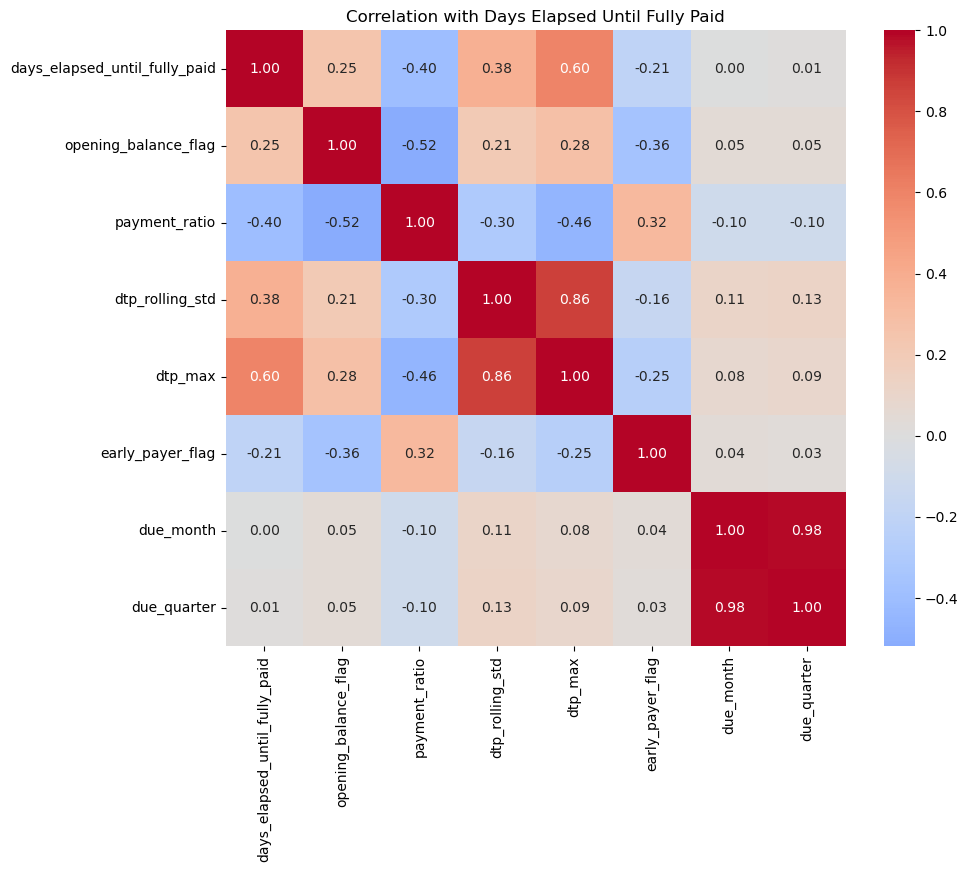

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

df_filtered = df_credit_sales[df_credit_sales['censor'] == 1]
df_filtered = df_filtered.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'])

# Select relevant columns
cols = ['days_elapsed_until_fully_paid', 'opening_balance_flag', 'payment_ratio',
        'dtp_rolling_std', 'dtp_max', 'early_payer_flag',
        'due_month', 'due_quarter']

# Compute correlation matrix
corr = df_filtered[cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Correlation with Days Elapsed Until Fully Paid")
plt.show()

### c. Linear Discriminant Analysis

In [14]:
df_credit_sales.columns

Index(['school_year', 'student_id_pseudonimized', 'category_name',
       'gross_receivables', 'amount_discounted', 'adjustments',
       'credit_sale_amount', 'due_date', 'date_fully_paid',
       'days_elapsed_until_fully_paid', 'dtp_1', 'dtp_2', 'dtp_3', 'dtp_4',
       'dtp_avg', 'dtp_wavg', 'due_date_prev_1', 'due_date_prev_2',
       'dtp_2_trend', 'dtp_3_trend', 'last_payment_date',
       'days_since_last_payment', 'amount_due_cumsum', 'amount_paid_cumsum',
       'opening_balance', 'plan_type_Plan - A', 'plan_type_Plan - B',
       'plan_type_Plan - C', 'plan_type_Plan - D', 'plan_type_Plan - E',
       'plan_type_nan', 'dtp_bracket', 'censor', 'due_month', 'due_quarter',
       'opening_balance_flag', 'payment_ratio', 'early_payer_flag',
       'on_time_streak', 'prev_bracket', 'dtp_rolling_std', 'dtp_max',
       'plan_type_risk_score'],
      dtype='object')

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
BRACKET_COL  = 'dtp_bracket'

DTP_FEATURES = ['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4', 'dtp_avg', 'dtp_wavg']
FIN_FEATURES = ['credit_sale_amount', 'opening_balance',
                'amount_due_cumsum', 'amount_paid_cumsum']
ALL_FEATURES = DTP_FEATURES + FIN_FEATURES + ['payment_ratio']

BRACKET_ORDER  = ['on_time', '30_days', '60_days', '90_days']
BRACKET_COLORS = {
    'on_time': '#2ecc71',
    '30_days': '#5dade2',
    '60_days': '#f0b27a',
    '90_days': '#e07b72',
}


# ─────────────────────────────────────────────
# DATA HELPERS
# ─────────────────────────────────────────────

def load_and_prepare(df):
    """Clean and split into X (float64) and y (bracket label)."""
    cols_needed = ALL_FEATURES + [BRACKET_COL]
    df_clean = df[cols_needed].dropna()
    df_clean = df_clean[df_clean[BRACKET_COL].isin(BRACKET_ORDER)]
    X = df_clean[ALL_FEATURES].astype(float).copy()
    y = df_clean[BRACKET_COL].copy()
    return X, y


def log1p_transform(X):
    """log1p-transform financial features; leave DTP features untouched."""
    X_t = X.astype(float).copy()
    for col in FIN_FEATURES:
        if col in X_t.columns:
            shift = abs(X_t[col].min()) if X_t[col].min() < 0 else 0
            X_t[col] = np.log1p(X_t[col] + shift)
    return X_t


def fit_lda(X, y):
    """Scale then fit LDA; return (pipeline, projected array, explained var ratio)."""
    n_components = min(len(BRACKET_ORDER) - 1, X.shape[1])   # max 3
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lda',    LinearDiscriminantAnalysis(n_components=n_components,
                                              solver='svd')),
    ])
    X_lda = pipe.fit_transform(X, y)
    evr   = pipe.named_steps['lda'].explained_variance_ratio_
    return pipe, X_lda, evr


def compute_class_separation(X, y):
    """Fisher between/within variance ratio per feature."""
    rows = []
    for col in X.columns:
        overall_mean = X[col].mean()
        classes      = y.unique()
        between = sum(
            (y == c).sum() * (X.loc[y == c, col].mean() - overall_mean) ** 2
            for c in classes
        ) / len(y)
        within = sum(
            X.loc[y == c, col].var() * (y == c).sum()
            for c in classes
        ) / len(y)
        rows.append({'feature': col,
                     'separation': between / within if within > 0 else 0})
    return pd.DataFrame(rows).sort_values('separation', ascending=False)


# ─────────────────────────────────────────────
# ATOMIC PLOT HELPERS
# ─────────────────────────────────────────────

def _draw_raw_hist(ax, col, y, feat, show_legend=False):
    """Overlapping density histogram for one raw feature."""
    col = col.astype(float)
    lo, hi = col.quantile(0.01), col.quantile(0.99)
    for bracket in BRACKET_ORDER:
        vals = col[y == bracket].clip(lo, hi)
        ax.hist(vals, bins=60, density=True, alpha=0.55,
                color=BRACKET_COLORS[bracket], label=bracket)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    if show_legend:
        ax.legend(fontsize=7, loc='upper right')


def _draw_ld_hist(ax, X_lda, y, evr, ld_idx, show_legend=False):
    """Density histogram for one LDA discriminant axis."""
    for bracket in BRACKET_ORDER:
        mask = (y == bracket).values
        ax.hist(X_lda[mask, ld_idx], bins=80, density=True, alpha=0.55,
                color=BRACKET_COLORS[bracket], label=bracket)
    ax.set_title(f'LD{ld_idx+1}  ({evr[ld_idx]*100:.1f}% sep. var.)',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel(f'LD{ld_idx+1} score', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    if show_legend:
        ax.legend(fontsize=7, loc='upper right')


def _draw_ld_scatter(ax, X_lda, y, evr):
    """LD1 vs LD2 2-D scatter coloured by bracket."""
    for bracket in BRACKET_ORDER:
        mask = (y == bracket).values
        ax.scatter(X_lda[mask, 0], X_lda[mask, 1],
                   s=5, alpha=0.28, color=BRACKET_COLORS[bracket],
                   label=bracket, rasterized=True)
    ax.set_xlabel(f'LD1  ({evr[0]*100:.1f}%)', fontsize=8)
    ld2_label = f'LD2  ({evr[1]*100:.1f}%)' if len(evr) > 1 else 'LD2'
    ax.set_ylabel(ld2_label, fontsize=8)
    ax.set_title('LD1 vs LD2 — 2-D projection', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, markerscale=3)
    ax.tick_params(labelsize=7)


def _col_header(ax, text, color):
    """Solid-background header label above an axis."""
    ax.annotate(text, xy=(0.5, 1.24), xycoords='axes fraction',
                ha='center', va='bottom', fontsize=11, fontweight='bold',
                color='white',
                bbox=dict(boxstyle='round,pad=0.4', fc=color,
                          alpha=0.85, ec='none'))


def _draw_separation_bar(ax, sep_before, sep_after):
    """Grouped bar chart: Fisher separation before vs after."""
    features = sep_before['feature'].tolist()
    x, w     = np.arange(len(features)), 0.35
    b_vals   = sep_before.set_index('feature').loc[features, 'separation'].values
    a_vals   = sep_after.set_index('feature').loc[features,  'separation'].values
    ax.bar(x - w/2, b_vals, w, label='Before (raw)',         color='#aab7b8')
    ax.bar(x + w/2, a_vals, w, label='After (log1p+scaled)', color='#5dade2')
    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel("Fisher's separation ratio", fontsize=9)
    ax.set_title("Per-feature class separation — before vs after log1p transform",
                 fontsize=10)
    ax.legend(fontsize=8)


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

def run_lda_analysis(df):
    """
    Two-column layout — one feature per row:

        LEFT  column  =  BEFORE  (raw histogram, p1–p99 clipped)
        RIGHT column  =  AFTER   (LDA component histogram)

    Feature rows:
        Rows 0–5   : dtp_1, dtp_2, dtp_3, dtp_4, dtp_avg, dtp_wavg
        Rows 6–10  : credit_sale_amount, opening_balance,
                     amount_due_cumsum, amount_paid_cumsum, payment_ratio

    Extra rows:
        Row 11 : [note | LD1 vs LD2 scatter]
        Row 12 : Fisher separation bar  (spans both columns)
    """
    # ── data ───────────────────────────────────
    X_raw, y         = load_and_prepare(df)
    X_t              = log1p_transform(X_raw)
    pipe, X_lda, evr = fit_lda(X_t, y)

    # console report
    print(f"\n{'='*55}")
    print("  LDA — Explained separation variance")
    print(f"{'='*55}")
    for i, v in enumerate(evr, 1):
        print(f"  LD{i}: {'█'*int(v*40):<40}  {v*100:.1f}%")
    print(f"{'='*55}\n")

    sep_before = compute_class_separation(X_raw, y)
    sep_after  = compute_class_separation(X_t,   y)
    merged = (sep_before.rename(columns={'separation': 'before'})
                         .merge(sep_after.rename(columns={'separation': 'after'}),
                                on='feature'))
    merged['improvement_%'] = ((merged['after'] - merged['before'])
                               / merged['before'].replace(0, np.nan) * 100)
    print(merged.to_string(index=False))

    # ── grid ───────────────────────────────────
    fin_plus  = FIN_FEATURES + ['payment_ratio']    # 5 features
    all_feats = DTP_FEATURES + fin_plus             # 11 total
    n_feats   = len(all_feats)
    n_ld      = X_lda.shape[1]                      # 3 at most

    # Right column content (after):
    #   Row 0        → LD1 histogram
    #   Row 1        → LD2 histogram
    #   Row 2        → LD3 histogram
    #   Row 3        → LD1 vs LD2 scatter  (spans remaining right cells via axis('off'))
    #   Rows 4–10    → empty (right side blank, left keeps all raw features)
    # Bottom row     → Fisher bar spanning both columns

    NROWS = n_feats + 1    # 11 feature rows + 1 bar row
    NCOLS = 2

    fig, axes = plt.subplots(
        NROWS, NCOLS,
        figsize=(14, NROWS * 2.6),
        gridspec_kw={'hspace': 0.80, 'wspace': 0.28}
    )
    fig.suptitle(
        "LDA Analysis — Before & After  |  dtp_bracket classification",
        fontsize=13, fontweight='bold', y=1.001
    )

    # column header badges on the first row
    _col_header(axes[0, 0], "◀  BEFORE  —  Raw feature distributions", '#922b21')
    _col_header(axes[0, 1], "AFTER  —  LDA discriminant components  ▶", '#1a5276')

    # ── LEFT column: all 11 raw feature histograms ──
    for i, feat in enumerate(all_feats):
        _draw_raw_hist(axes[i, 0], X_raw[feat], y, feat,
                       show_legend=(i == 0))

    # ── RIGHT column ────────────────────────────────
    # Rows 0–(n_ld-1): one LD histogram each
    for ld_idx in range(n_ld):
        _draw_ld_hist(axes[ld_idx, 1], X_lda, y, evr, ld_idx,
                      show_legend=(ld_idx == 0))

    # Row n_ld: LD1 vs LD2 scatter
    _draw_ld_scatter(axes[n_ld, 1], X_lda, y, evr)

    # Rows (n_ld+1) onward on the right: turn off (left keeps raw hists)
    for i in range(n_ld + 1, n_feats):
        axes[i, 1].axis('off')

    # ── Fisher bar row — spans both columns ─────────
    br = n_feats
    for c in range(NCOLS):
        axes[br, c].axis('off')

    pos_l  = axes[br, 0].get_position()
    pos_r  = axes[br, 1].get_position()
    bar_ax = fig.add_axes([
        pos_l.x0,
        pos_l.y0,
        pos_r.x1 - pos_l.x0,
        pos_l.height * 1.8
    ])
    _draw_separation_bar(bar_ax, sep_before, sep_after)

    plt.savefig('Images/lda_before_after.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSaved → lda_before_after.png")

    return pipe, X_lda, evr, merged


# ─────────────────────────────────────────────
# USAGE
# ─────────────────────────────────────────────
# pipe, X_lda, evr, sep_df = run_lda_analysis(df_credit_sales)
#
# Inject LD components back into your dataframe for modelling:
#   X_raw, y = load_and_prepare(df_credit_sales)
#   X_t      = log1p_transform(X_raw)
#   comps    = pipe.transform(X_t)
#   for i in range(comps.shape[1]):
#       df_credit_sales.loc[X_raw.index, f'LD{i+1}'] = comps[:, i]


  LDA — Explained separation variance
  LD1: ██████████████████████████████████        85.6%
  LD2: █████                                     14.0%
  LD3:                                           0.4%

           feature   before    after  improvement_%
   opening_balance 0.361174 1.320293     265.556135
          dtp_wavg 0.290850 0.290850       0.000000
           dtp_avg 0.284166 0.284166       0.000000
     payment_ratio 0.239790 0.239790       0.000000
             dtp_1 0.212042 0.212042       0.000000
             dtp_2 0.205817 0.205817       0.000000
             dtp_3 0.176547 0.176547       0.000000
             dtp_4 0.150549 0.150549       0.000000
amount_paid_cumsum 0.040752 0.048623      19.314570
 amount_due_cumsum 0.018528 0.018299      -1.234113
credit_sale_amount 0.015961 0.022742      42.490940


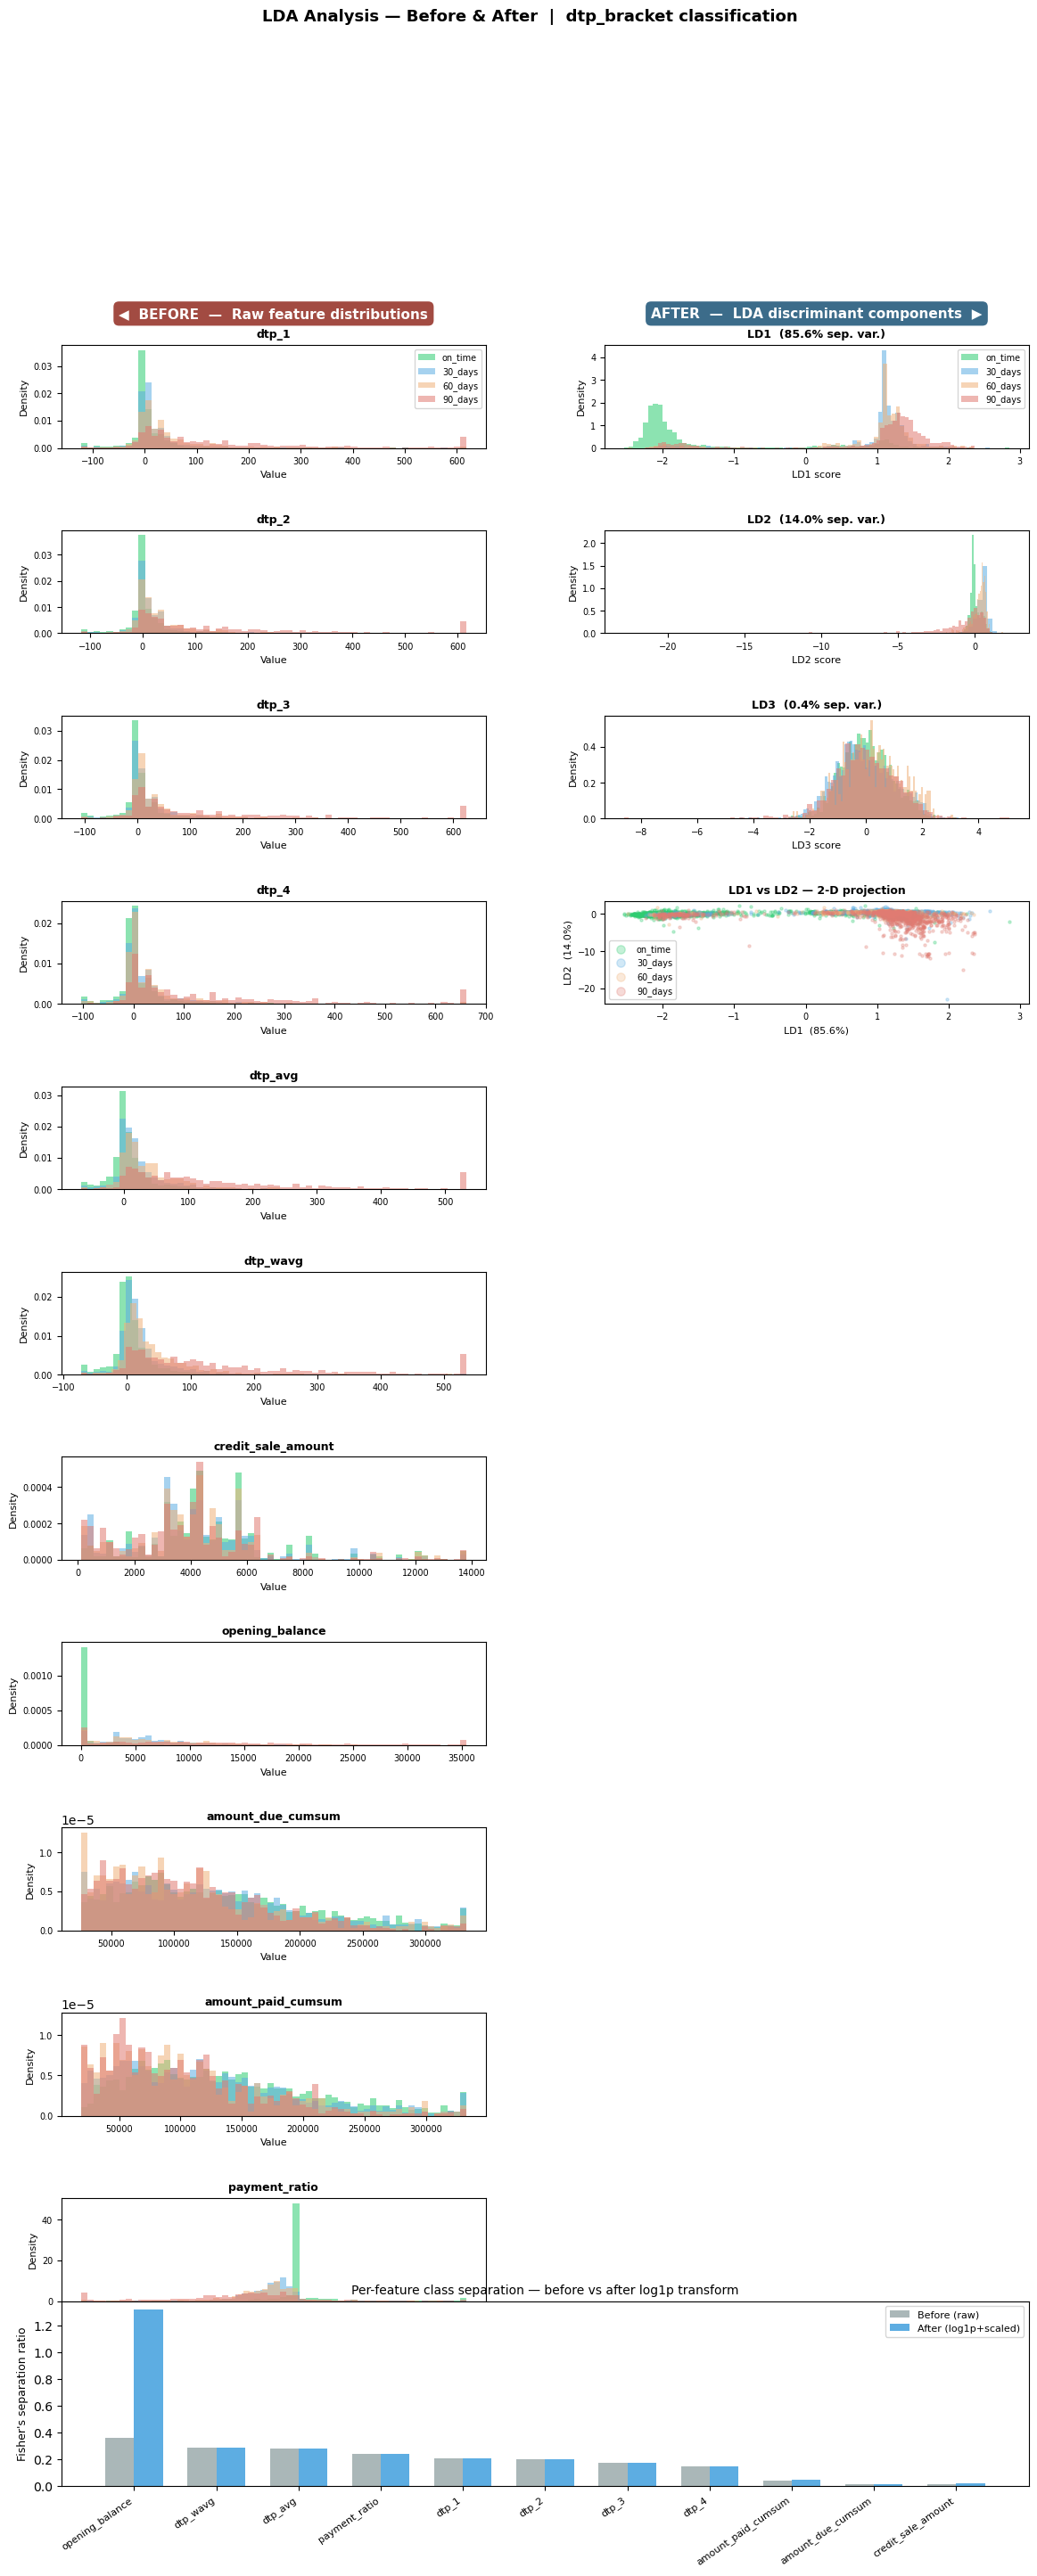


Saved → lda_before_after.png


(Pipeline(steps=[('scaler', StandardScaler()),
                 ('lda', LinearDiscriminantAnalysis(n_components=3))]),
 array([[-1.8133913 , -0.34327797,  1.84167765],
        [-1.83197996, -0.20888648,  1.73448743],
        [ 0.49713937,  0.67893446,  0.88264153],
        ...,
        [ 1.26159324,  0.53976502, -1.57692688],
        [ 1.17921519,  0.6918276 , -1.08978224],
        [-2.06389521, -0.18365694, -0.80085842]], shape=(6417, 3)),
 array([0.8559215 , 0.13979942, 0.00427909]),
                feature    before     after  improvement_%
 0      opening_balance  0.361174  1.320293     265.556135
 1             dtp_wavg  0.290850  0.290850       0.000000
 2              dtp_avg  0.284166  0.284166       0.000000
 3        payment_ratio  0.239790  0.239790       0.000000
 4                dtp_1  0.212042  0.212042       0.000000
 5                dtp_2  0.205817  0.205817       0.000000
 6                dtp_3  0.176547  0.176547       0.000000
 7                dtp_4  0.150549  0.

In [16]:
run_lda_analysis(df_credit_sales)

### d. LDA (Delinquent)

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
BRACKET_COL  = 'dtp_bracket'

DTP_FEATURES = ['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4', 'dtp_avg', 'dtp_wavg']
FIN_FEATURES = ['credit_sale_amount', 'opening_balance',
                'amount_due_cumsum', 'amount_paid_cumsum']
ALL_FEATURES = DTP_FEATURES + FIN_FEATURES + ['payment_ratio']

BRACKET_ORDER  = ['30_days', '60_days', '90_days']  # on_time excluded
BRACKET_COLORS = {
    'on_time': '#2ecc71',
    '30_days': '#5dade2',
    '60_days': '#f0b27a',
    '90_days': '#e07b72',
}


# ─────────────────────────────────────────────
# DATA HELPERS
# ─────────────────────────────────────────────

def load_and_prepare(df):
    """Clean and split into X (float64) and y (bracket label)."""
    cols_needed = ALL_FEATURES + [BRACKET_COL]
    df_clean = df[cols_needed].dropna()
    df_clean = df_clean[df_clean[BRACKET_COL].isin(BRACKET_ORDER)]
    X = df_clean[ALL_FEATURES].astype(float).copy()
    y = df_clean[BRACKET_COL].copy()
    return X, y


def log1p_transform(X):
    """log1p-transform financial features; leave DTP features untouched."""
    X_t = X.astype(float).copy()
    for col in FIN_FEATURES:
        if col in X_t.columns:
            shift = abs(X_t[col].min()) if X_t[col].min() < 0 else 0
            X_t[col] = np.log1p(X_t[col] + shift)
    return X_t


def fit_lda(X, y):
    """Scale then fit LDA; return (pipeline, projected array, explained var ratio)."""
    n_components = min(len(BRACKET_ORDER) - 1, X.shape[1])   # max 3
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lda',    LinearDiscriminantAnalysis(n_components=n_components,
                                              solver='svd')),
    ])
    X_lda = pipe.fit_transform(X, y)
    evr   = pipe.named_steps['lda'].explained_variance_ratio_
    return pipe, X_lda, evr


def compute_class_separation(X, y):
    """Fisher between/within variance ratio per feature."""
    rows = []
    for col in X.columns:
        overall_mean = X[col].mean()
        classes      = y.unique()
        between = sum(
            (y == c).sum() * (X.loc[y == c, col].mean() - overall_mean) ** 2
            for c in classes
        ) / len(y)
        within = sum(
            X.loc[y == c, col].var() * (y == c).sum()
            for c in classes
        ) / len(y)
        rows.append({'feature': col,
                     'separation': between / within if within > 0 else 0})
    return pd.DataFrame(rows).sort_values('separation', ascending=False)


# ─────────────────────────────────────────────
# ATOMIC PLOT HELPERS
# ─────────────────────────────────────────────

def _draw_raw_hist(ax, col, y, feat, show_legend=False):
    """Overlapping density histogram for one raw feature."""
    col = col.astype(float)
    lo, hi = col.quantile(0.01), col.quantile(0.99)
    for bracket in BRACKET_ORDER:
        vals = col[y == bracket].clip(lo, hi)
        ax.hist(vals, bins=60, density=True, alpha=0.55,
                color=BRACKET_COLORS[bracket], label=bracket)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    if show_legend:
        ax.legend(fontsize=7, loc='upper right')


def _draw_ld_hist(ax, X_lda, y, evr, ld_idx, show_legend=False):
    """Density histogram for one LDA discriminant axis."""
    for bracket in BRACKET_ORDER:
        mask = (y == bracket).values
        ax.hist(X_lda[mask, ld_idx], bins=80, density=True, alpha=0.55,
                color=BRACKET_COLORS[bracket], label=bracket)
    ax.set_title(f'LD{ld_idx+1}  ({evr[ld_idx]*100:.1f}% sep. var.)',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel(f'LD{ld_idx+1} score', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    if show_legend:
        ax.legend(fontsize=7, loc='upper right')


def _draw_ld_scatter(ax, X_lda, y, evr):
    """LD1 vs LD2 2-D scatter coloured by bracket."""
    for bracket in BRACKET_ORDER:
        mask = (y == bracket).values
        ax.scatter(X_lda[mask, 0], X_lda[mask, 1],
                   s=5, alpha=0.28, color=BRACKET_COLORS[bracket],
                   label=bracket, rasterized=True)
    ax.set_xlabel(f'LD1  ({evr[0]*100:.1f}%)', fontsize=8)
    ld2_label = f'LD2  ({evr[1]*100:.1f}%)' if len(evr) > 1 else 'LD2'
    ax.set_ylabel(ld2_label, fontsize=8)
    ax.set_title('LD1 vs LD2 — 2-D projection', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, markerscale=3)
    ax.tick_params(labelsize=7)


def _col_header(ax, text, color):
    """Solid-background header label above an axis."""
    ax.annotate(text, xy=(0.5, 1.24), xycoords='axes fraction',
                ha='center', va='bottom', fontsize=11, fontweight='bold',
                color='white',
                bbox=dict(boxstyle='round,pad=0.4', fc=color,
                          alpha=0.85, ec='none'))


def _draw_separation_bar(ax, sep_before, sep_after):
    """Grouped bar chart: Fisher separation before vs after."""
    features = sep_before['feature'].tolist()
    x, w     = np.arange(len(features)), 0.35
    b_vals   = sep_before.set_index('feature').loc[features, 'separation'].values
    a_vals   = sep_after.set_index('feature').loc[features,  'separation'].values
    ax.bar(x - w/2, b_vals, w, label='Before (raw)',         color='#aab7b8')
    ax.bar(x + w/2, a_vals, w, label='After (log1p+scaled)', color='#5dade2')
    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel("Fisher's separation ratio", fontsize=9)
    ax.set_title("Per-feature class separation — before vs after log1p transform",
                 fontsize=10)
    ax.legend(fontsize=8)


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

def run_lda_analysis_delinquent(df):
    """
    Two-column layout — one feature per row:

        LEFT  column  =  BEFORE  (raw histogram, p1–p99 clipped)
        RIGHT column  =  AFTER   (LDA component histogram)

    Feature rows:
        Rows 0–5   : dtp_1, dtp_2, dtp_3, dtp_4, dtp_avg, dtp_wavg
        Rows 6–10  : credit_sale_amount, opening_balance,
                     amount_due_cumsum, amount_paid_cumsum, payment_ratio

    Extra rows:
        Row 11 : [note | LD1 vs LD2 scatter]
        Row 12 : Fisher separation bar  (spans both columns)
    """
    # ── data ───────────────────────────────────
    X_raw, y         = load_and_prepare(df)
    X_t              = log1p_transform(X_raw)
    pipe, X_lda, evr = fit_lda(X_t, y)

    # console report
    print(f"\n{'='*55}")
    print("  LDA — Explained separation variance")
    print(f"{'='*55}")
    for i, v in enumerate(evr, 1):
        print(f"  LD{i}: {'█'*int(v*40):<40}  {v*100:.1f}%")
    print(f"{'='*55}\n")

    sep_before = compute_class_separation(X_raw, y)
    sep_after  = compute_class_separation(X_t,   y)
    merged = (sep_before.rename(columns={'separation': 'before'})
                         .merge(sep_after.rename(columns={'separation': 'after'}),
                                on='feature'))
    merged['improvement_%'] = ((merged['after'] - merged['before'])
                               / merged['before'].replace(0, np.nan) * 100)
    print(merged.to_string(index=False))

    # ── grid ───────────────────────────────────
    fin_plus  = FIN_FEATURES + ['payment_ratio']    # 5 features
    all_feats = DTP_FEATURES + fin_plus             # 11 total
    n_feats   = len(all_feats)
    n_ld      = X_lda.shape[1]                      # 3 at most

    # Right column content (after):
    #   Row 0        → LD1 histogram
    #   Row 1        → LD2 histogram
    #   Row 2        → LD3 histogram
    #   Row 3        → LD1 vs LD2 scatter  (spans remaining right cells via axis('off'))
    #   Rows 4–10    → empty (right side blank, left keeps all raw features)
    # Bottom row     → Fisher bar spanning both columns

    NROWS = n_feats + 1    # 11 feature rows + 1 bar row
    NCOLS = 2

    fig, axes = plt.subplots(
        NROWS, NCOLS,
        figsize=(14, NROWS * 2.6),
        gridspec_kw={'hspace': 0.80, 'wspace': 0.28}
    )
    fig.suptitle(
        "LDA Analysis — Delinquent Only (30 / 60 / 90 days)  |  on_time excluded",
        fontsize=13, fontweight='bold', y=1.001
    )

    # column header badges on the first row
    _col_header(axes[0, 0], "◀  BEFORE  —  Raw feature distributions", '#922b21')
    _col_header(axes[0, 1], "AFTER  —  LDA discriminant components  ▶", '#1a5276')

    # ── LEFT column: all 11 raw feature histograms ──
    for i, feat in enumerate(all_feats):
        _draw_raw_hist(axes[i, 0], X_raw[feat], y, feat,
                       show_legend=(i == 0))

    # ── RIGHT column ────────────────────────────────
    # Rows 0–(n_ld-1): one LD histogram each
    for ld_idx in range(n_ld):
        _draw_ld_hist(axes[ld_idx, 1], X_lda, y, evr, ld_idx,
                      show_legend=(ld_idx == 0))

    # Row n_ld: LD1 vs LD2 scatter
    _draw_ld_scatter(axes[n_ld, 1], X_lda, y, evr)

    # Rows (n_ld+1) onward on the right: turn off (left keeps raw hists)
    for i in range(n_ld + 1, n_feats):
        axes[i, 1].axis('off')

    # ── Fisher bar row — spans both columns ─────────
    br = n_feats
    for c in range(NCOLS):
        axes[br, c].axis('off')

    pos_l  = axes[br, 0].get_position()
    pos_r  = axes[br, 1].get_position()
    bar_ax = fig.add_axes([
        pos_l.x0,
        pos_l.y0,
        pos_r.x1 - pos_l.x0,
        pos_l.height * 1.8
    ])
    _draw_separation_bar(bar_ax, sep_before, sep_after)

    plt.savefig('lda_delinquent_only.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nSaved → lda_delinquent_only.png")

    return pipe, X_lda, evr, merged


# ─────────────────────────────────────────────
# USAGE
# ─────────────────────────────────────────────
# pipe, X_lda, evr, sep_df = run_lda_analysis(df_credit_sales)  # delinquent only
#
# Inject LD components back into your dataframe for modelling:
#   X_raw, y = load_and_prepare(df_credit_sales)
#   X_t      = log1p_transform(X_raw)
#   comps    = pipe.transform(X_t)
#   for i in range(comps.shape[1]):
#       df_credit_sales.loc[X_raw.index, f'LD{i+1}'] = comps[:, i]


  LDA — Explained separation variance
  LD1: ██████████████████████████████████████    96.1%
  LD2: █                                         3.9%

           feature   before    after  improvement_%
          dtp_wavg 0.224989 0.224989       0.000000
           dtp_avg 0.221574 0.221574       0.000000
             dtp_2 0.167507 0.167507       0.000000
             dtp_1 0.163770 0.163770       0.000000
             dtp_3 0.140743 0.140743       0.000000
             dtp_4 0.128166 0.128166       0.000000
   opening_balance 0.122377 0.000370     -99.697542
     payment_ratio 0.073323 0.073323       0.000000
amount_paid_cumsum 0.023621 0.023181      -1.861703
 amount_due_cumsum 0.014399 0.011971     -16.863216
credit_sale_amount 0.002283 0.003891      70.437948


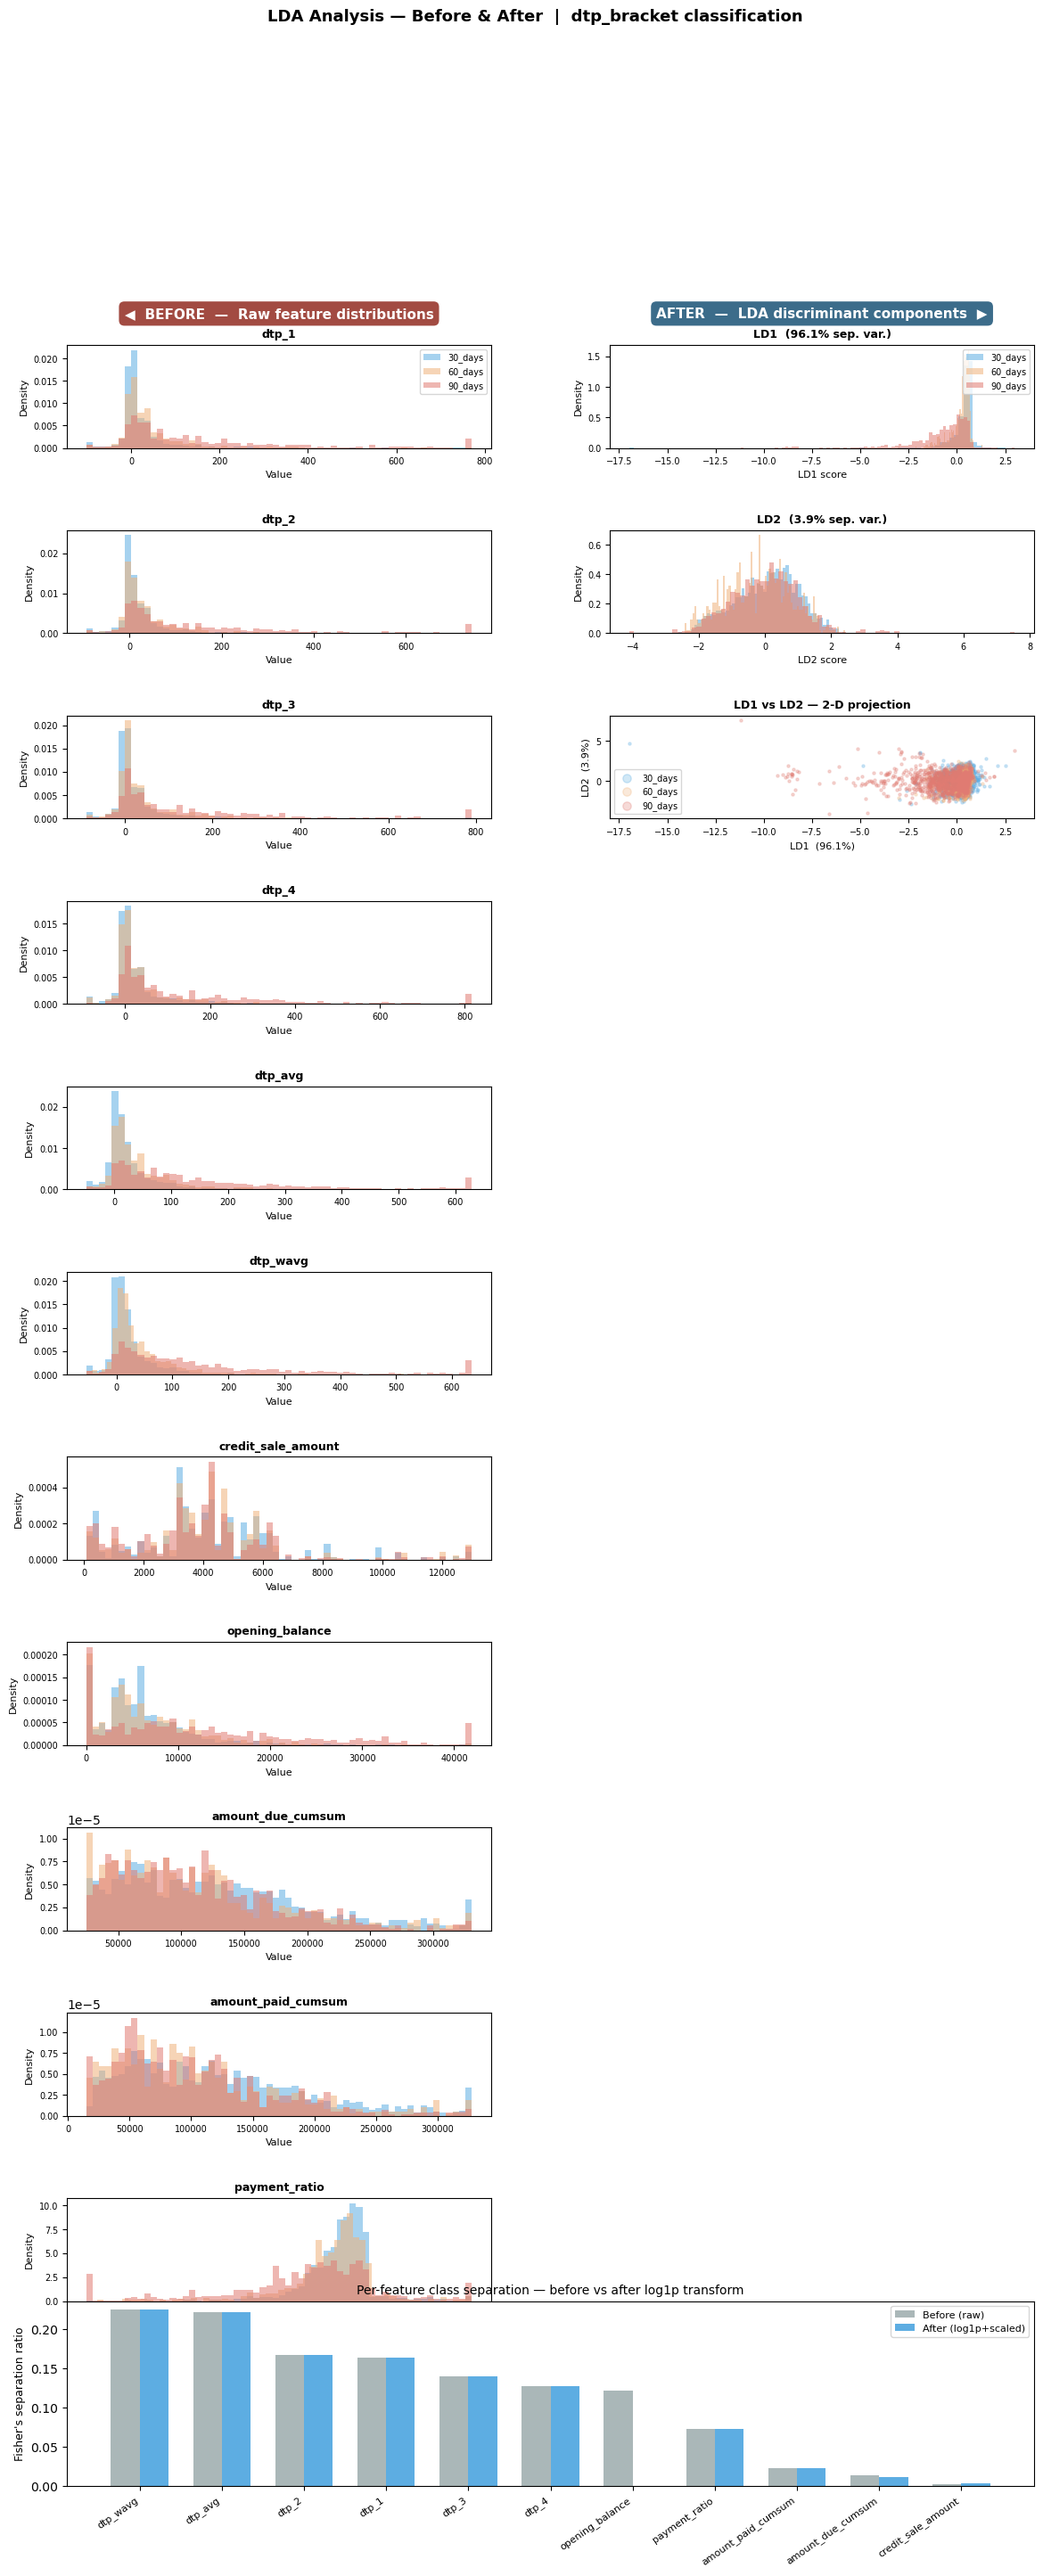


Saved → lda_before_after.png


(Pipeline(steps=[('scaler', StandardScaler()),
                 ('lda', LinearDiscriminantAnalysis(n_components=2))]),
 array([[-0.39685895, -0.16605083],
        [ 0.14820521,  0.25788517],
        [ 0.39814367,  0.83344067],
        ...,
        [ 0.42828572,  1.24261344],
        [ 0.52532609,  1.44212738],
        [ 0.59691546,  1.08270771]], shape=(3841, 2)),
 array([0.96114013, 0.03885987]),
                feature    before     after  improvement_%
 0             dtp_wavg  0.224989  0.224989       0.000000
 1              dtp_avg  0.221574  0.221574       0.000000
 2                dtp_2  0.167507  0.167507       0.000000
 3                dtp_1  0.163770  0.163770       0.000000
 4                dtp_3  0.140743  0.140743       0.000000
 5                dtp_4  0.128166  0.128166       0.000000
 6      opening_balance  0.122377  0.000370     -99.697542
 7        payment_ratio  0.073323  0.073323       0.000000
 8   amount_paid_cumsum  0.023621  0.023181      -1.861703
 9    amo

In [18]:
run_lda_analysis(df_credit_sales)

# D. Machine Learning Pipelines

## 1. Single model trainer

### a. Load the raw dataset

In [ ]:
# ── 1. Load settings ────────────────────────────────────────────────────────────────────────
from datetime import datetime
from utils.data_loaders.read_settings_json import read_settings_json

settings = read_settings_json(file_path="settings.json")
observation_end = datetime.strptime(settings['Training']['observation_end'], "%Y/%m/%d")
target_feature = settings["Training"]["target_feature"]
test_size = float(settings["Training"]["test_size"])

class Settings:
    observation_end = observation_end
    target_feature = target_feature
    test_size = test_size                                                 # Test size in %
    
args = Settings()



# ── 2. Load the invoice dataset ─────────────────────────────────────────────────────────
from feature_engineering.credit_sales_machine_learning import CreditSalesProcessor

cs = CreditSalesProcessor(
    df_revenues, df_enrollees, args,
    drop_demographic_columns=True,
    drop_fully_paid_invoices=False,
    drop_helper_columns=True,
    drop_missing_dtp=True,
    add_streak_features=True,
    exclude_school_years=[2016, 2017, 2018],
    winsorise_dtp=True)
df_credit_sales = cs.show_data()



# ── 3. Load the dataset for machine learning and for survival analysis ───────────────────
survival_columns = ['days_elapsed_until_fully_paid', 'censor']
non_survival_columns = ['due_date', 'dtp_bracket']


df_data = df_credit_sales[df_credit_sales['censor'] == 1].copy()
df_data.drop(columns=survival_columns, inplace=True)

df_data_surv = df_credit_sales.drop(columns=non_survival_columns)



# ── 4. Optimizing the CoxPH Model ─────────────────────────────────────────────────────────
from machine_learning.utils.features.adjust_survival_time_periods import adjust_payment_period
from machine_learning.utils.features.get_slope_time_points import get_slope_timepoints
from machine_learning.utils.training.tune_cox_hyperparameters import CoxHyperparameterTuner

X_surv = df_data_surv.drop(columns=survival_columns)
T      = adjust_payment_period(df_data_surv["days_elapsed_until_fully_paid"])
E      = df_data_surv["censor"]

# Focused grid based on empirical results — high l1_ratio wins consistently
tuner = CoxHyperparameterTuner(
    alpha_grid       = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
    l1_ratios        = [0.5, 0.75, 1.0],
)
tuner.fit(X_surv, T, E)

best_time_points = get_slope_timepoints(T, E, n_points=9)


best_surv_parameters = tuner.best_params_
best_time_points = best_time_points



# ── 5. Data Preparation ──────────────────────────────────────────────────────────────
from machine_learning.utils.data.data_preparation import DataPreparer

preparer = DataPreparer(
    df_data,
    target_feature=args.target_feature,
    test_size=args.test_size
)
preparer.encode_labels().train_test_split()
preparer.resample(balance_strategy="smote")

X_train = preparer.X_train
X_test = preparer.X_test
y_train = preparer.y_train
y_test = preparer.y_test



# ── 6. Generate survival features ──────────────────────────────────────────────────────────────
from machine_learning.utils.features.generate_survival_features import generate_survival_features

df_survival_train, df_survival_test = generate_survival_features(
    X_surv, T, E, X_train, X_test,
    best_params=best_surv_parameters,
    time_points=best_time_points
)

### d. Generate survival features

### e. Train models

In [66]:
model_parameters = {
    "learning_rate": 0.1,
    "n_estimators": 50,
    "random_state": 42
}

In [ ]:
from machine_learning import AdaBoostPipeline

pipeline = AdaBoostPipeline(
    X_train, X_test, y_train, y_test,
    args,
    model_parameters
)

# Capture results from pipeline
result = pipeline.initialize_model().fit(use_feature_selection=True).evaluate().show_results()
selected_features = pipeline.features

In [70]:
selected_features.weights

{'credit_sale_amount': 0.0,
 'dtp_1': 0.0,
 'dtp_2': 0.0,
 'dtp_3': 0.0,
 'dtp_4': 0.0,
 'dtp_avg': 0.207422,
 'dtp_wavg': 0.098081,
 'dtp_2_trend': 0.0,
 'dtp_3_trend': 0.0,
 'days_since_last_payment': 0.0,
 'amount_due_cumsum': 0.0,
 'amount_paid_cumsum': 0.0,
 'opening_balance': 0.694497,
 'plan_type_Plan - A': 0.0,
 'plan_type_Plan - B': 0.0,
 'plan_type_Plan - C': 0.0,
 'plan_type_Plan - D': 0.0,
 'plan_type_Plan - E': 0.0,
 'plan_type_nan': 0.0,
 'due_month': 0.0,
 'due_quarter': 0.0,
 'opening_balance_flag': 0.0,
 'payment_ratio': 0.0,
 'early_payer_flag': 0.0,
 'dtp_rolling_std': 0.0,
 'dtp_max': 0.0,
 'plan_type_risk_score': 0.0}

## 2. Multiple model trainer

### b. Hyperparameter tuning (various balancing strategies, parameters, and models)

In [ ]:
from machine_learning import (
    AdaBoostPipeline,
    DecisionTreePipeline,
    GaussianNaiveBayesPipeline,
    KNearestNeighborPipeline,
    RandomForestPipeline,
    XGBoostPipeline,
    StackedEnsemblePipeline,
    MultiLayerPerceptronPipeline,
    TransformerPipeline,
)

models = {
    #"ada_boost": AdaBoostPipeline,
    #"decision_tree": DecisionTreePipeline,
    #"gaussian_naive_bayes": GaussianNaiveBayesPipeline,
    #"knn": KNearestNeighborPipeline,
    #"random_forest": RandomForestPipeline,
    #"xgboost": XGBoostPipeline,
    #"stacked_ensemble": StackedEnsemblePipeline,
    #"nn_mlp": MultiLayerPerceptronPipeline,
    #"nn_rnn": RecurrentNeuralNetworkPipeline,
    #"nn_transformer": TransformerPipeline
}

# Since these models are trained in the GPU, it's best
# to not to parallel compute to avoid bugs
do_not_parallel_compute = ['xg_boost', 'nn_mlp', 'nn_transformer']

In [ ]:
from machine_learning.utils.features.generate_thresholds import generate_thresholds

#balance_strategies = ["smote", "borderline_smote", "smoteenn", "smotetomek", "hybrid"]
balance_strategies = ["borderline_smote", "smote_enn", "smote_tomek"]

# thresholds used in the hybrid approach
thresholds = generate_thresholds(min_threshold=0.5, max_threshold=0.9, step=0.1)

In [ ]:
# To silence the error when running knn:
# UserWarning: Could not find the number of physical cores for the following reason:
# [WinError 2]
import os

os.environ['OMP_NUM_THREADS'] = '16'

In [ ]:
# Older method used to debug if there are any changes in the model's code
if False:
    from MachineLearning.Utils.run_models_single_threaded import run_survival_model_experiments

    df_results = run_survival_model_experiments(df_data_surv, models, balance_strategies, args, best_penalty, thresholds)

In [ ]:
# Helper columns
drop_columns = ['school_year', 'student_id_pseudonimized', 'category_name',
       'gross_receivables', 'amount_discounted', 'adjustments', 'due_date_prev_1',
       'due_date_prev_2', 'date_fully_paid', 'last_payment_date']

# Payment plans
#drop_columns = drop_columns + ['plan_type_Plan - A', 'plan_type_Plan - B', 'plan_type_Plan - C',
#                               'plan_type_Plan - D', 'plan_type_Plan - E', 'plan_type_nan']

# Survival related features
drop_columns = drop_columns + ['censor', 'days_elapsed_until_fully_paid']

# Only extract invoices with payments
df_data = df_credit_sales[df_credit_sales['censor'] == 1]

df_data = df_data.drop(columns=drop_columns)

# Drop invoices with missing critical features
df_data.dropna(subset=['dtp_1', 'dtp_2', 'dtp_3', 'dtp_4'], inplace=True)
df_data

In [ ]:
from machine_learning.models.stacked_ensemble import StackedEnsemblePipeline
from machine_learning.utils.features.generate_survival_features import generate_survival_features


args = {}

df_surv = df_data_surv.copy()

X = df_surv.drop(columns=['days_elapsed_until_fully_paid', 'censor'])
T = df_surv['days_elapsed_until_fully_paid']
E = df_surv['censor']

# Avoid negative values by shifting by the days of pre-paid period
earliest_payment = np.minimum(T, 0) # Maximum to only get pre-payments
ε = 1e-6 # Used to avoid zero values
T = T - earliest_payment + ε

X_surv_train, X_test_test = generate_survival_features(X, T, E, X_train, X_test, best_params, time_points=[16, 30, 58, 76, 118, 150, 284, 306])


estimators={
    "adaboost":      {"learning_rate": 0.1, "n_estimators": 10},
    "random_forest": {"max_depth": 10, "min_samples_leaf": 1, "n_estimators": 100},
}

sep = StackedEnsemblePipeline(X_surv_train, X_test_test, y_train, y_test, args)
sep.initialize_model(estimators=estimators).fit(use_feature_selection=False, threshold="median")

In [ ]:
result_baseline = sep.evaluate().show_results()

In [ ]:
sep.features.weights

In [ ]:
from machine_learning.utils.training.run_models_parallel import SurvivalExperimentRunner

# Create an experiment runner instance
runner = SurvivalExperimentRunner(
    df_data=df_data,
    df_data_surv=df_data_surv,
    models=models,
    balance_strategies=balance_strategies,
    args=args,
    best_parameters=best_params,
    thresholds=thresholds,
    n_jobs=-1,
    do_not_parallel_compute=do_not_parallel_compute,

    feature_selection_baseline=True,
    feature_selection_enhanced=True
)

# Run experiments
df_results = runner.run()

In [ ]:
df_results

In [ ]:
df_results.sort_values(by='enhanced_accuracy', ascending=False)

In [ ]:
df_results.sort_values(by='enhanced_precision_macro', ascending=False)

In [ ]:
df_results.sort_values(by='enhanced_f1_macro', ascending=False)

In [ ]:
df_results.sort_values(by='enhanced_roc_auc_macro', ascending=False)

In [ ]:
import pandas as pd

# File path
file_path = r"C:\Users\rjbel\Python\Notebooks\Mapua\Thesis\MachineLearning\Results\06 model_results - no feature selection.xlsx"

# Read the Excel file
df = pd.read_excel(file_path)

# Choose which score column to use
score_column = "enhanced_roc_auc_macro"   # <-- change this to the metric you want (e.g., "f1", "roc_auc", etc.)

# Create a combined column: balance_strategy + threshold (only for hybrid)
df["balance_strategy_full"] = df.apply(
    lambda row: f"{row['balance_strategy']}_{row['undersample_threshold']}"
    if row["balance_strategy"] == "hybrid" else row["balance_strategy"],
    axis=1
)

# Compute mean score per model+parameters+strategy
grouped = (
    df.groupby(["model", "parameters", "balance_strategy_full"])[score_column]
    .mean()
    .reset_index()
)

# Rank strategies within each model+parameters group
grouped["rank"] = grouped.groupby(["model", "parameters"])[score_column] \
                         .rank(method="first", ascending=False)

# Assign weighted points: top 1 → 5, top 2 → 4, … top 5 → 1
def assign_points(rank):
    if rank == 1: return 5
    elif rank == 2: return 4
    elif rank == 3: return 3
    elif rank == 4: return 2
    elif rank == 5: return 1
    else: return 0

grouped["points"] = grouped["rank"].apply(assign_points)

# Aggregate across all models to see total points per strategy
strategy_scores = (
    grouped.groupby("balance_strategy_full")["points"]
    .sum()
    .reset_index()
    .sort_values("points", ascending=False)
)

# Show results
print("Weighted ranking per model+parameters:")
print(grouped.sort_values(["model", "parameters", "rank"]))

print("\nGlobal tally of weighted points per balance strategy:")
print(strategy_scores)

In [ ]:
import pandas as pd

# File path
file_path = r"C:\Users\rjbel\Python\Notebooks\Mapua\Thesis\Results\08 - model_results - fixed enhancement features (with feature selection).xlsx"

# Read the Excel file
df = pd.read_excel(file_path)

# Choose which score column to use
score_column = "enhanced_f1_macro"   # <-- change this to the metric you want (e.g., "f1", "roc_auc", etc.)

# Create a combined column: balance_strategy + threshold (only for hybrid)
df["balance_strategy_full"] = df.apply(
    lambda row: f"{row['balance_strategy']}_{row['undersample_threshold']}"
    if row["balance_strategy"] == "hybrid" else row["balance_strategy"],
    axis=1
)

# Compute mean score per model+parameters+strategy
grouped = (
    df.groupby(["model", "parameters", "balance_strategy_full"])[score_column]
    .mean()
    .reset_index()
)

# Rank strategies within each model+parameters group
grouped["rank"] = grouped.groupby(["model", "parameters"])[score_column] \
                         .rank(method="first", ascending=False)

# Assign weighted points: top 1 → 5, top 2 → 4, … top 5 → 1
def assign_points(rank):
    if rank == 1: return 5
    elif rank == 2: return 4
    elif rank == 3: return 3
    elif rank == 4: return 2
    elif rank == 5: return 1
    else: return 0

grouped["points"] = grouped["rank"].apply(assign_points)

# Aggregate across all models to see total points per strategy
strategy_scores = (
    grouped.groupby("balance_strategy_full")["points"]
    .sum()
    .reset_index()
    .sort_values("points", ascending=False)
)

# Show results
print("Weighted ranking per model+parameters:")
print(grouped.sort_values(["model", "parameters", "rank"]))

print("\nGlobal tally of weighted points per balance strategy:")
print(strategy_scores)

In [ ]:
import pickle
import os

run_folder_path = r"C:\Users\rjbel\Python\Notebooks\Mapua\Thesis\Results\2026_03_06_03"

with open(os.path.join(run_folder_path, "results.pkl"), "rb") as f:
        results_df = pickle.load(f)

results_df

In [ ]:
results_df.to_excel('Results/Test.xlsx', index=False)

## c. Forecasting pipeline

In [ ]:
from feature_engineering.credit_sales_machine_learning import CreditSales

cs_test = CreditSales(df_revenues, df_enrollees, args,
                      drop_fully_paid_invoices=True,
                      drop_back_account_transactions=True,
                      calculate_payment_amounts=True,
                      add_description=True,
                      drop_missing_dtp=False)
df_cs_test = cs_test.show_data()
df_cs_test

In [ ]:
from machine_learning.utils.io.migrate_db_schema import 